# PyTorch 신경망으로 콘크리트 강도 예측

구성:
1. 데이터 업로드 및 읽기
2. Min-Max 정규화
3. 훈련/테스트 데이터 분리
4. 은닉 노드 1개 모델 학습
5. 은닉 노드 5개 모델 학습
6. 은닉층 2개와 Softplus 활성화 함수 모델 학습
7. 예측값과 실제값의 상관계수 비교


In [1]:
# PyTorch, pandas, numpy, matplotlib 등 필요한 라이브러리를 불러옵니다.
# torch는 신경망 모델 생성, 텐서 연산, 학습에 사용하는 핵심 라이브러리입니다.
# pandas는 CSV 파일을 표 형태 데이터프레임으로 읽고 처리하는 데 사용합니다.
# numpy는 수치 계산과 상관계수 계산에 사용합니다.
# matplotlib은 학습 손실 그래프를 그리는 데 사용합니다.
# os는 파일 경로 존재 여부를 확인하는 데 사용합니다.
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Google Colab에서 파일 업로드 기능을 사용하기 위해 files 모듈을 불러옵니다.
# 로컬 PC에 있는 concrete_stg.csv 파일을 Colab 실행 환경으로 업로드할 때 사용합니다.
# from google.colab import files

# 실행 결과를 동일하게 재현하기 위해 난수 시드를 고정합니다.
# 신경망의 초기 가중치와 데이터 처리 과정에서 발생할 수 있는 무작위성을 일정하게 만듭니다.
SEED = 12345

# Python 기본 random 모듈의 난수 시드를 고정합니다.
random.seed(SEED)

# numpy의 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 사용 가능한 경우 GPU 연산의 난수 시드도 고정합니다.
torch.cuda.manual_seed_all(SEED)

# Colab 런타임에서 GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용합니다.
# device는 이후 텐서와 모델을 어느 장치에서 계산할지 지정하는 변수입니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 사용 중인 연산 장치를 출력합니다.
print('사용 장치:', device)

사용 장치: cuda


In [2]:
# concrete_stg.csv 파일 경로를 지정합니다.
# Colab에 직접 업로드하면 현재 작업 폴더에 concrete_stg.csv 이름으로 저장됩니다.
CSV_PATH = 'concrete_stg.csv'

# 파일이 현재 작업 폴더에 없는 경우 업로드 창을 실행합니다.
# 업로드 창에서 concrete_stg.csv 파일을 선택해야 합니다.
if not os.path.exists(CSV_PATH):
    print('concrete_stg.csv 파일을 업로드하세요.')
    uploaded = files.upload()

    # 업로드된 파일 목록에서 첫 번째 파일명을 가져옵니다.
    uploaded_filename = list(uploaded.keys())[0]

    # 업로드한 파일명이 concrete_stg.csv와 다르면 CSV_PATH를 실제 업로드 파일명으로 변경합니다.
    CSV_PATH = uploaded_filename

# pandas의 read_csv()로 CSV 파일을 데이터프레임으로 읽습니다.
# 데이터프레임은 행과 열로 구성된 표 형태의 데이터 구조입니다.
concrete_stg = pd.read_csv(CSV_PATH)

# 데이터의 처음 5행을 출력하여 열 이름과 값의 형태를 확인합니다.
display(concrete_stg.head())

# 데이터 행 개수, 열 개수, 결측치, 자료형을 확인합니다.
# 신경망에 넣기 전에 모든 입력값이 숫자형인지 확인하는 단계입니다.
concrete_stg.info()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [3]:
# 데이터의 기초 통계량을 확인합니다.
# count는 데이터 개수, mean은 평균, std는 표준편차입니다.
# min과 max는 각 열의 최솟값과 최댓값입니다.
display(concrete_stg.describe())

# 모델 입력에 사용할 특성 열 이름을 리스트로 지정합니다.
# 이 8개 열은 콘크리트 강도를 예측하기 위한 입력 변수입니다.
feature_cols = ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']

# 모델이 예측해야 하는 목표 열 이름을 지정합니다.
# strength는 콘크리트 강도 값입니다.
target_col = 'strength'

# 필요한 열이 데이터에 모두 존재하는지 확인합니다.
# 누락된 열이 있으면 파일 구조가 예상과 다르므로 오류를 발생시킵니다.
required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in concrete_stg.columns]
if missing_cols:
    raise ValueError(f'CSV 파일에 다음 열이 없습니다: {missing_cols}')

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [4]:
# Min-Max 정규화 함수를 정의합니다.
# 각 열의 값을 0과 1 사이 범위로 변환합니다.
# 신경망은 입력값의 범위가 비슷할 때 더 안정적으로 학습됩니다.
def min_max_normalize(series):
    # 열의 최솟값을 구합니다.
    min_value = series.min()

    # 열의 최댓값을 구합니다.
    max_value = series.max()

    # 최댓값과 최솟값이 같으면 나눗셈이 불가능하므로 0으로 채운 열을 반환합니다.
    if max_value == min_value:
        return pd.Series(np.zeros(len(series)), index=series.index)

    # Min-Max 정규화 공식입니다.
    # 현재값에서 최솟값을 뺀 뒤, 최댓값과 최솟값의 차이로 나눕니다.
    return (series - min_value) / (max_value - min_value)

# 전체 데이터프레임의 각 열에 Min-Max 정규화를 적용합니다.
# apply()는 데이터프레임의 열 단위로 함수를 적용합니다.
concrete_stg_norm = concrete_stg.apply(min_max_normalize)

# 정규화된 strength 값의 기초 통계량을 확인합니다.
# min은 0, max는 1에 가까운 값이어야 합니다.
print('정규화된 strength 통계량')
display(concrete_stg_norm[target_col].describe())

# 원본 strength 값의 기초 통계량을 확인합니다.
# 원래 강도 값의 범위와 정규화 후 범위를 비교하기 위한 출력입니다.
print('원본 strength 통계량')
display(concrete_stg[target_col].describe())

정규화된 strength 통계량


count    1030.000000
mean        0.417191
std         0.208119
min         0.000000
25%         0.266351
50%         0.400087
75%         0.545721
max         1.000000
Name: strength, dtype: float64

원본 strength 통계량


count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: strength, dtype: float64

In [5]:
display(concrete_stg_norm.describe())

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,0.409059,0.205609,0.270806,0.477374,0.192691,0.499764,0.450528,0.122698,0.417191
std,0.238599,0.240065,0.319825,0.170561,0.185523,0.226029,0.201144,0.173544,0.208119
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.206336,0.000000,0.000000,0.344249,0.000000,0.380814,0.343578,0.016484,0.266351
50%,0.390183,0.061213,0.000000,0.504792,0.198758,0.485465,0.465379,0.074176,0.400087
75%,0.566210,0.397746,0.591204,0.560703,0.316770,0.663953,0.577020,0.151099,0.545721
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# 정규화된 데이터에서 앞 780개 행을 훈련 데이터로 사용합니다.
train_df = concrete_stg_norm.iloc[:780].copy()

# 정규화된 데이터에서 781번째 행부터 1030번째 행까지를 테스트 데이터로 사용합니다.
# Python의 iloc는 끝 인덱스를 포함하지 않으므로 780:1030으로 지정합니다.
test_df = concrete_stg_norm.iloc[780:1030].copy()

# 훈련 입력 데이터를 numpy 배열로 변환합니다.
# astype(np.float32)는 PyTorch에서 사용하기 적합한 32비트 실수형으로 변환합니다.
X_train_np = train_df[feature_cols].values.astype(np.float32)

# 훈련 정답 데이터를 numpy 배열로 변환합니다.
# reshape(-1, 1)은 출력값을 2차원 형태로 만들어 모델 출력 모양과 맞춥니다.
y_train_np = train_df[target_col].values.astype(np.float32).reshape(-1, 1)

# 테스트 입력 데이터를 numpy 배열로 변환합니다.
X_test_np = test_df[feature_cols].values.astype(np.float32)

# 테스트 정답 데이터를 numpy 배열로 변환합니다.
y_test_np = test_df[target_col].values.astype(np.float32).reshape(-1, 1)

# numpy 배열을 PyTorch 텐서로 변환하고 연산 장치로 이동합니다.
# 텐서는 PyTorch에서 사용하는 다차원 숫자 배열입니다.
X_train = torch.tensor(X_train_np).to(device)
y_train = torch.tensor(y_train_np).to(device)
X_test = torch.tensor(X_test_np).to(device)
y_test = torch.tensor(y_test_np).to(device)

# 훈련 데이터와 테스트 데이터의 모양을 출력합니다.
# 입력 데이터는 행 개수 x 입력 특성 개수 형태입니다.
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: torch.Size([780, 8])
y_train: torch.Size([780, 1])
X_test: torch.Size([250, 8])
y_test: torch.Size([250, 1])


In [7]:
# 신경망 모델 클래스를 정의합니다.
# nn.Module을 상속하면 PyTorch 학습 모델로 사용할 수 있습니다.
class ConcreteANN(nn.Module):
    # 생성자에서는 입력 크기, 은닉층 구조, 활성화 함수를 받습니다.
    def __init__(self, input_dim, hidden_layers, activation='sigmoid'):
        # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # 신경망 계층들을 순서대로 담을 리스트를 생성합니다.
        layers = []

        # 첫 번째 계층의 입력 크기는 입력 변수 개수입니다.
        prev_dim = input_dim

        # hidden_layers 리스트에 들어 있는 은닉 노드 수를 하나씩 사용하여 은닉층을 만듭니다.
        for hidden_dim in hidden_layers:
            # 선형 계층은 입력값에 가중치와 바이어스를 적용합니다.
            layers.append(nn.Linear(prev_dim, hidden_dim))

            # activation 값에 따라 활성화 함수를 선택합니다.
            # sigmoid는 출력을 0과 1 사이로 압축하는 함수입니다.
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())

            # softplus는 log(1 + exp(x)) 형태의 부드러운 비선형 함수입니다.
            elif activation == 'softplus':
                layers.append(nn.Softplus())

            # 지원하지 않는 활성화 함수명이 들어오면 오류를 발생시킵니다.
            else:
                raise ValueError('activation은 sigmoid 또는 softplus만 사용할 수 있습니다.')

            # 다음 계층의 입력 크기는 현재 은닉층의 출력 크기와 같습니다.
            prev_dim = hidden_dim

        # 마지막 출력 계층을 추가합니다.
        # 회귀 문제이므로 출력 노드는 strength 예측값 1개입니다.
        layers.append(nn.Linear(prev_dim, 1))

        # 리스트에 담긴 계층들을 순서대로 실행하는 Sequential 모델로 묶습니다.
        self.network = nn.Sequential(*layers)

    # forward는 입력 데이터가 모델을 통과하는 계산 과정을 정의합니다.
    def forward(self, x):
        # 입력 x를 network에 넣어 예측값을 반환합니다.
        return self.network(x)

In [8]:
# 모델 학습 함수를 정의합니다.
# model은 학습할 신경망입니다.
# epochs는 전체 훈련 데이터를 몇 번 반복해서 학습할지 정합니다.
# lr은 학습률이며, 가중치를 한 번에 얼마나 조정할지 결정합니다.
def train_model(model, X_train, y_train, epochs=5000, lr=0.01, print_every=500):
    # 모델을 지정한 연산 장치로 이동합니다.
    model = model.to(device)

    # 평균제곱오차 손실 함수를 생성합니다.
    # 회귀 예측에서 예측값과 실제값의 차이를 제곱하여 평균한 값입니다.
    criterion = nn.MSELoss()

    # Adam 최적화 알고리즘을 생성합니다.
    # optimizer는 손실을 줄이는 방향으로 모델의 가중치를 업데이트합니다.
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # epoch별 손실값을 저장할 리스트입니다.
    loss_history = []

    # 지정한 epoch 횟수만큼 학습을 반복합니다.
    for epoch in range(1, epochs + 1):
        # 모델을 학습 모드로 전환합니다.
        model.train()

        # 이전 반복에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad()

        # 훈련 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        y_pred = model(X_train)

        # 예측값과 실제값 사이의 손실을 계산합니다.
        loss = criterion(y_pred, y_train)

        # 손실값을 기준으로 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 이용해 가중치를 업데이트합니다.
        optimizer.step()

        # 현재 epoch의 손실값을 Python 숫자로 변환하여 저장합니다.
        loss_history.append(loss.item())

        # print_every 간격마다 학습 진행 상황을 출력합니다.
        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f}')

    # 학습이 완료된 모델과 손실 이력을 반환합니다.
    return model, loss_history

# 평가 함수를 정의합니다.
# 테스트 데이터에 대한 예측값, 실제값과의 상관계수, MSE를 계산합니다.
def evaluate_model(model, X_test, y_test):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 평가 단계에서는 기울기를 계산하지 않습니다.
    # 불필요한 메모리 사용을 줄이고 예측 속도를 높입니다.
    with torch.no_grad():
        # 테스트 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        pred = model(X_test)

        # 테스트 손실값을 계산합니다.
        mse = nn.MSELoss()(pred, y_test).item()

    # 예측값 텐서를 CPU로 이동한 뒤 numpy 배열로 변환합니다.
    pred_np = pred.cpu().numpy().reshape(-1)

    # 실제값 텐서를 CPU로 이동한 뒤 numpy 배열로 변환합니다.
    true_np = y_test.cpu().numpy().reshape(-1)

    # 예측값과 실제값의 피어슨 상관계수를 계산합니다.
    # 1에 가까울수록 예측값과 실제값이 같은 방향으로 강하게 움직입니다.
    corr = np.corrcoef(pred_np, true_np)[0, 1]

    # 예측값, 상관계수, 평균제곱오차를 반환합니다.
    return pred_np, corr, mse

# 손실 그래프를 그리는 함수를 정의합니다.
def plot_loss(loss_history, title):
    # 그래프 크기를 지정합니다.
    plt.figure(figsize=(8, 4))

    # epoch별 손실값을 선 그래프로 표시합니다.
    plt.plot(loss_history)

    # 그래프 제목을 지정합니다.
    plt.title(title)

    # x축 이름을 지정합니다.
    plt.xlabel('Epoch')

    # y축 이름을 지정합니다.
    plt.ylabel('MSE Loss')

    # 그래프 격자를 표시합니다.
    plt.grid(True)

    # 그래프를 화면에 출력합니다.
    plt.show()

ConcreteANN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=1, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=1, out_features=1, bias=True)
  )
)
Epoch     1 | Loss: 0.651267
Epoch   500 | Loss: 0.041758
Epoch  1000 | Loss: 0.016887
Epoch  1500 | Loss: 0.014352
Epoch  2000 | Loss: 0.013703
Epoch  2500 | Loss: 0.013526
Epoch  3000 | Loss: 0.013459
Epoch  3500 | Loss: 0.013414
Epoch  4000 | Loss: 0.013363
Epoch  4500 | Loss: 0.013300
Epoch  5000 | Loss: 0.013234


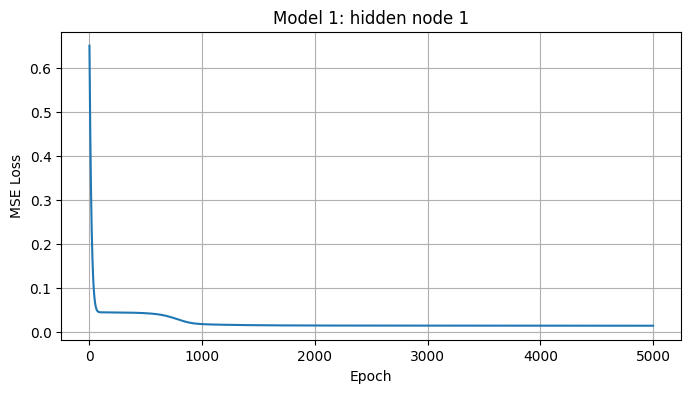

Model 1 상관계수: 0.7995
Model 1 테스트 MSE: 0.014928


In [9]:
# 입력 변수 개수를 계산합니다.
# feature_cols에 8개 입력 변수가 있으므로 input_dim은 8입니다.
input_dim = len(feature_cols)

# 은닉 노드 1개를 가진 단순 신경망 모델을 생성합니다.
model1 = ConcreteANN(input_dim=input_dim, hidden_layers=[1], activation='sigmoid')

# 모델 구조를 출력합니다.
print(model1)

# 모델1을 학습합니다.
# epochs와 lr은 실행 환경에 따라 조정할 수 있습니다.
model1, loss1 = train_model(model1, X_train, y_train, epochs=5000, lr=0.01, print_every=500)

# 모델1의 손실 변화를 그래프로 확인합니다.
plot_loss(loss1, 'Model 1: hidden node 1')

# 테스트 데이터로 모델1을 평가합니다.
pred1, corr1, mse1 = evaluate_model(model1, X_test, y_test)

# 모델1의 평가 결과를 출력합니다.
print(f'Model 1 상관계수: {corr1:.4f}')
print(f'Model 1 테스트 MSE: {mse1:.6f}')

ConcreteANN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)
Epoch     1 | Loss: 0.088105
Epoch   800 | Loss: 0.009366
Epoch  1600 | Loss: 0.006909
Epoch  2400 | Loss: 0.005884
Epoch  3200 | Loss: 0.004960
Epoch  4000 | Loss: 0.004630
Epoch  4800 | Loss: 0.004517
Epoch  5600 | Loss: 0.004444
Epoch  6400 | Loss: 0.004362
Epoch  7200 | Loss: 0.004284
Epoch  8000 | Loss: 0.004230


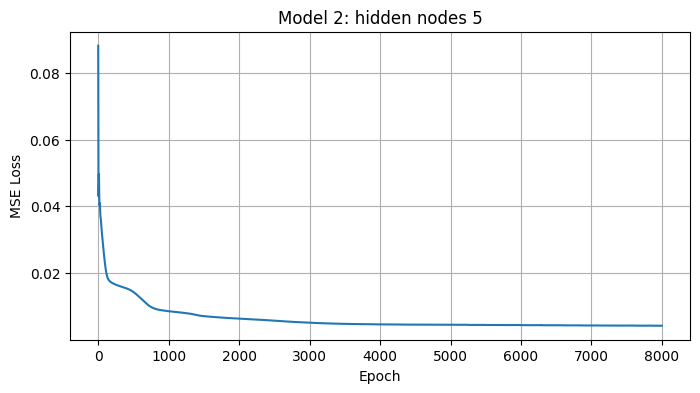

Model 2 상관계수: 0.9286
Model 2 테스트 MSE: 0.005687


In [10]:
# 은닉 노드 5개를 가진 신경망 모델을 생성합니다.
# 은닉 노드가 늘어나면 입력 변수 사이의 복잡한 비선형 관계를 더 잘 표현할 수 있습니다.
model2 = ConcreteANN(input_dim=input_dim, hidden_layers=[5], activation='sigmoid')

# 모델 구조를 출력합니다.
print(model2)

# 모델2를 학습합니다.
# 은닉 노드 수가 증가했기 때문에 모델1보다 더 많은 패턴을 학습할 수 있습니다.
model2, loss2 = train_model(model2, X_train, y_train, epochs=8000, lr=0.01, print_every=800)

# 모델2의 손실 변화를 그래프로 확인합니다.
plot_loss(loss2, 'Model 2: hidden nodes 5')

# 테스트 데이터로 모델2를 평가합니다.
pred2, corr2, mse2 = evaluate_model(model2, X_test, y_test)

# 모델2의 평가 결과를 출력합니다.
print(f'Model 2 상관계수: {corr2:.4f}')
print(f'Model 2 테스트 MSE: {mse2:.6f}')

ConcreteANN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=5, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
    (4): Linear(in_features=5, out_features=1, bias=True)
  )
)
Epoch     1 | Loss: 0.055829
Epoch  1000 | Loss: 0.007674
Epoch  2000 | Loss: 0.006223
Epoch  3000 | Loss: 0.005931
Epoch  4000 | Loss: 0.005760
Epoch  5000 | Loss: 0.005568
Epoch  6000 | Loss: 0.005359
Epoch  7000 | Loss: 0.005237
Epoch  8000 | Loss: 0.005150
Epoch  9000 | Loss: 0.005067
Epoch 10000 | Loss: 0.004988


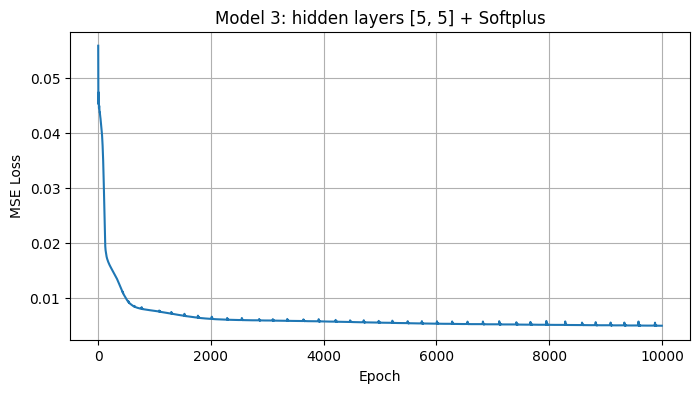

Model 3 상관계수: 0.9256
Model 3 테스트 MSE: 0.005893


In [11]:
# 은닉층 2개와 Softplus 활성화 함수를 사용하는 신경망 모델을 생성합니다.
# hidden_layers=[5, 5]는 첫 번째 은닉층 5개 노드, 두 번째 은닉층 5개 노드를 의미합니다.
# activation='softplus'는 사용자 정의 softplus 함수 log(1 + exp(x))에 대응합니다.
model3 = ConcreteANN(input_dim=input_dim, hidden_layers=[5, 5], activation='softplus')

# 모델 구조를 출력합니다.
print(model3)

# 모델3을 학습합니다.
# 계층이 깊어지면 표현력은 증가하지만 학습 시간이 더 길어질 수 있습니다.
model3, loss3 = train_model(model3, X_train, y_train, epochs=10000, lr=0.005, print_every=1000)

# 모델3의 손실 변화를 그래프로 확인합니다.
plot_loss(loss3, 'Model 3: hidden layers [5, 5] + Softplus')

# 테스트 데이터로 모델3을 평가합니다.
pred3, corr3, mse3 = evaluate_model(model3, X_test, y_test)

# 모델3의 평가 결과를 출력합니다.
print(f'Model 3 상관계수: {corr3:.4f}')
print(f'Model 3 테스트 MSE: {mse3:.6f}')

In [12]:
# 세 모델의 평가 결과를 하나의 표로 정리합니다.
# 상관계수는 높을수록 좋고, 테스트 MSE는 낮을수록 좋습니다.
results_df = pd.DataFrame({
    'model': [
        'Model 1: hidden node 1',
        'Model 2: hidden nodes 5',
        'Model 3: hidden layers [5, 5] + Softplus'
    ],
    'correlation': [corr1, corr2, corr3],
    'test_mse': [mse1, mse2, mse3]
})

# 결과 표를 출력합니다.
display(results_df)

,model,correlation,test_mse
0,Model 1: hidden node 1,0.799515,0.014928
1,Model 2: hidden nodes 5,0.928629,0.005687
2,"Model 3: hidden layers [5, 5] + Softplus",0.925614,0.005893


In [13]:
# 실제값과 예측값 일부를 비교하는 데이터프레임을 만듭니다.
# 모델이 테스트 데이터에서 어떤 값을 예측했는지 직접 확인할 수 있습니다.
compare_df = pd.DataFrame({
    'actual_strength_norm': y_test.cpu().numpy().reshape(-1),
    'pred_model1': pred1,
    'pred_model2': pred2,
    'pred_model3': pred3
})

# 앞쪽 10개 행만 출력합니다.
display(compare_df.head(10))

,actual_strength_norm,pred_model1,pred_model2,pred_model3
0,0.471160,0.564312,0.481002,0.462710
1,0.362402,0.324807,0.298286,0.298172
2,0.229226,0.218026,0.287898,0.262797
3,0.030522,0.033114,-0.012396,0.006211
4,0.546904,0.556454,0.674908,0.619985
5,0.389062,0.566815,0.473191,0.461629
6,0.261866,0.556599,0.417829,0.447050
7,0.381089,0.533306,0.367124,0.403964
8,0.486359,0.620419,0.641653,0.654599
9,0.380217,0.524960,0.552986,0.712494


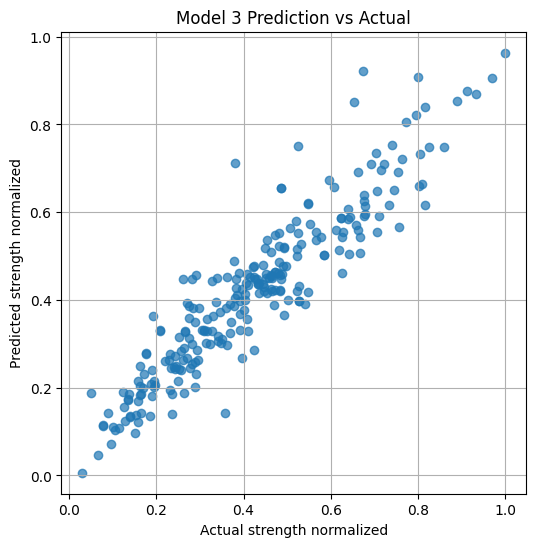

In [14]:
# 실제값과 예측값의 관계를 산점도로 확인합니다.
# 점들이 대각선 형태에 가까울수록 예측이 실제값과 잘 맞는 것입니다.
plt.figure(figsize=(6, 6))
plt.scatter(compare_df['actual_strength_norm'], compare_df['pred_model3'], alpha=0.7)
plt.xlabel('Actual strength normalized')
plt.ylabel('Predicted strength normalized')
plt.title('Model 3 Prediction vs Actual')
plt.grid(True)
plt.show()

In [15]:
# 정규화된 예측값을 원래 strength 단위로 되돌리는 함수를 정의합니다.
# 원래 단위로 복원하면 콘크리트 강도를 실제 수치 범위에서 해석할 수 있습니다.
def inverse_min_max(normalized_values, original_series):
    # 원본 strength의 최솟값을 구합니다.
    min_value = original_series.min()

    # 원본 strength의 최댓값을 구합니다.
    max_value = original_series.max()

    # 정규화 복원 공식입니다.
    # normalized * (max - min) + min 형태로 원래 단위 값을 계산합니다.
    return normalized_values * (max_value - min_value) + min_value

# 테스트 실제값을 원래 strength 단위로 복원합니다.
actual_strength_original = inverse_min_max(compare_df['actual_strength_norm'].values, concrete_stg[target_col])

# 모델3 예측값을 원래 strength 단위로 복원합니다.
pred_strength_original = inverse_min_max(compare_df['pred_model3'].values, concrete_stg[target_col])

# 원래 단위의 실제값과 예측값을 비교하는 표를 만듭니다.
original_compare_df = pd.DataFrame({
    'actual_strength': actual_strength_original,
    'predicted_strength_model3': pred_strength_original
})

# 앞쪽 10개 행만 출력합니다.
display(original_compare_df.head(10))

,actual_strength,predicted_strength_model3
0,40.150001,39.471746
1,31.420001,26.264252
2,20.730000,23.424677
3,4.780000,2.828517
4,46.230001,52.096228
5,33.560001,39.384962
6,23.350001,38.214725
7,32.920000,34.756196
8,41.370001,54.874663
9,32.850001,59.521923


## 정리

- `Model 1`은 은닉 노드 1개를 사용한 가장 단순한 신경망입니다.
- `Model 2`는 은닉 노드 5개를 사용하여 모델 표현력을 높인 구조입니다.
- `Model 3`은 은닉층 2개와 Softplus 활성화 함수를 사용한 더 깊은 구조입니다.
- 테스트 MSE가 낮고 상관계수가 높은 모델일수록 콘크리트 강도 예측 성능이 더 좋다고 해석할 수 있습니다.
